In [3]:
#Importing Python Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#importing functions and metrics from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest,f_regression
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

#theme for visualisation
plt.style.use('bmh')

In [4]:
#reading the csv file and printing first 5 rows
df=pd.read_csv('used_device_data.csv')
print(df.head(5))

  device_brand       os  screen_size   4g   5g  rear_camera_mp  \
0        Honor  Android        14.50  yes   no            13.0   
1        Honor  Android        17.30  yes  yes            13.0   
2        Honor  Android        16.69  yes  yes            13.0   
3        Honor  Android        25.50  yes  yes            13.0   
4        Honor  Android        15.32  yes   no            13.0   

   front_camera_mp  internal_memory  ram  battery  weight  release_year  \
0              5.0             64.0  3.0   3020.0   146.0          2020   
1             16.0            128.0  8.0   4300.0   213.0          2020   
2              8.0            128.0  8.0   4200.0   213.0          2020   
3              8.0             64.0  6.0   7250.0   480.0          2020   
4              8.0             64.0  3.0   5000.0   185.0          2020   

   days_used  normalized_used_price  normalized_new_price  
0        127               4.307572              4.715100  
1        325               5.162

In [5]:
#Getting overall information of the dataset
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   device_brand           3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   object 
 4   5g                     3454 non-null   object 
 5   rear_camera_mp         3275 non-null   float64
 6   front_camera_mp        3452 non-null   float64
 7   internal_memory        3450 non-null   float64
 8   ram                    3450 non-null   float64
 9   battery                3448 non-null   float64
 10  weight                 3447 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price   3454 non-null   float64
dtypes: f

,screen_size,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
count,3454.000000,3275.000000,3452.000000,3450.000000,3450.000000,3448.000000,3447.000000,3454.000000,3454.000000,3454.000000,3454.000000
mean,13.713115,9.460208,6.554229,54.573099,4.036122,3133.402697,182.751871,2015.965258,674.869716,4.364712,5.233107
std,3.805280,4.815461,6.970372,84.972371,1.365105,1299.682844,88.413228,2.298455,248.580166,0.588914,0.683637
min,5.080000,0.080000,0.000000,0.010000,0.020000,500.000000,69.000000,2013.000000,91.000000,1.536867,2.901422
25%,12.700000,5.000000,2.000000,16.000000,4.000000,2100.000000,142.000000,2014.000000,533.500000,4.033931,4.790342
50%,12.830000,8.000000,5.000000,32.000000,4.000000,3000.000000,160.000000,2015.500000,690.500000,4.405133,5.245892
75%,15.340000,13.000000,8.000000,64.000000,4.000000,4000.000000,185.000000,2018.000000,868.750000,4.755700,5.673718
max,30.710000,48.000000,32.000000,1024.000000,12.000000,9720.000000,855.000000,2020.000000,1094.000000,6.619433,7.847841


In [6]:
#Checking for missing values
df.isnull().sum()


device_brand               0
os                         0
screen_size                0
4g                         0
5g                         0
rear_camera_mp           179
front_camera_mp            2
internal_memory            4
ram                        4
battery                    6
weight                     7
release_year               0
days_used                  0
normalized_used_price      0
normalized_new_price       0
dtype: int64

In [7]:
#Checking for duplicated values
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
3449    False
3450    False
3451    False
3452    False
3453    False
Length: 3454, dtype: bool

In [8]:
#filling the null values with median
num_cols=['rear_camera_mp','front_camera_mp','internal_memory','battery','ram','weight']
for col in num_cols:
    df[col].fillna(df[col].median(),inplace=True)

C:\Users\rksan_amz5yv3\AppData\Local\Temp\ipykernel_19220\3269481060.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)


In [9]:
df.isnull().sum()

device_brand             0
os                       0
screen_size              0
4g                       0
5g                       0
rear_camera_mp           0
front_camera_mp          0
internal_memory          0
ram                      0
battery                  0
weight                   0
release_year             0
days_used                0
normalized_used_price    0
normalized_new_price     0
dtype: int64

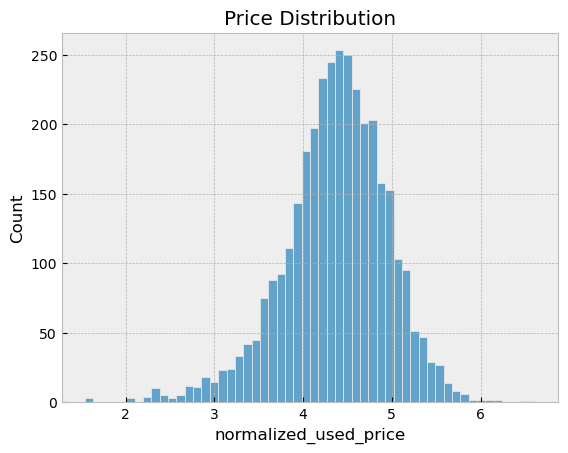

In [10]:
#EDA
sns.histplot(df['normalized_used_price'])
plt.title("Price Distribution")
plt.show()

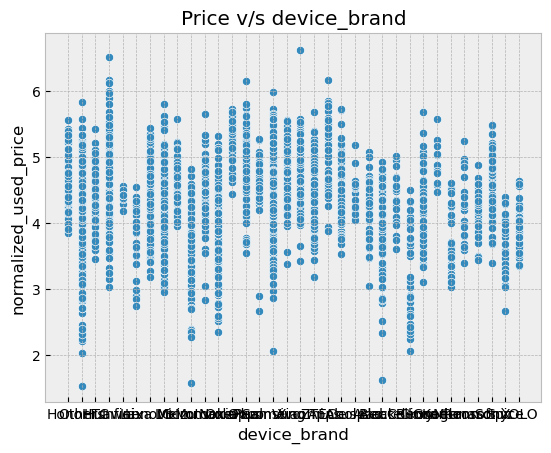

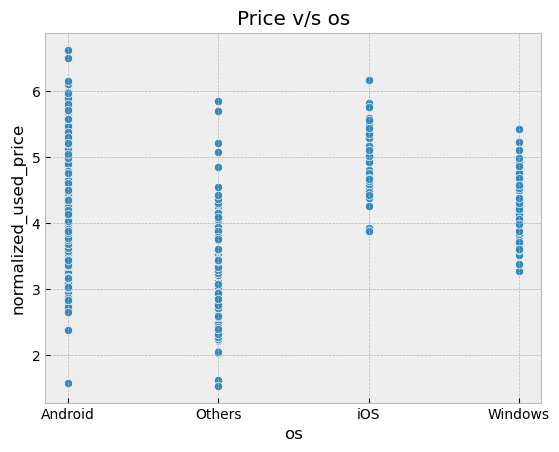

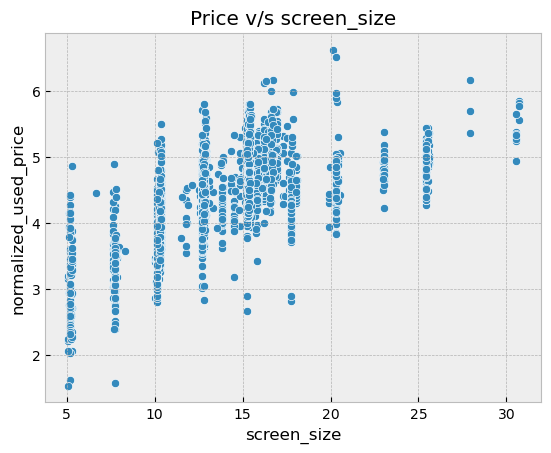

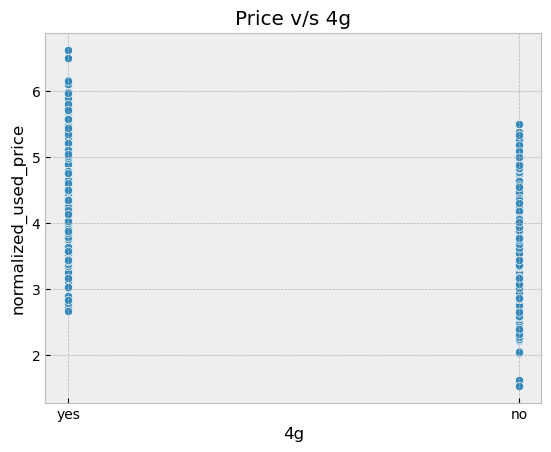

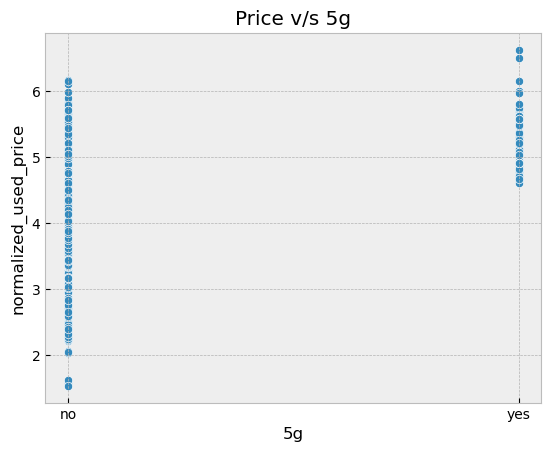

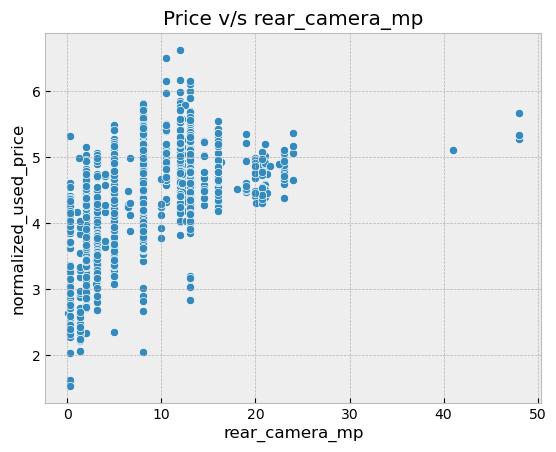

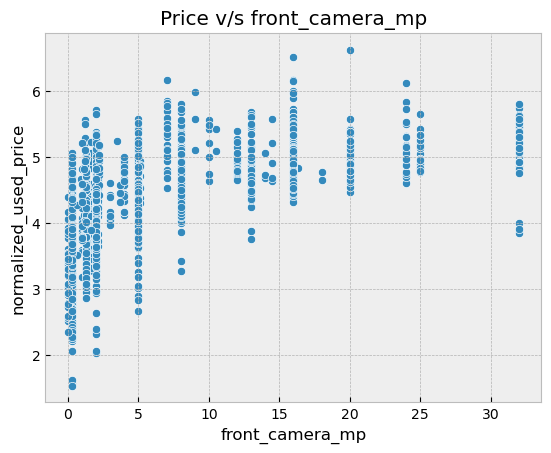

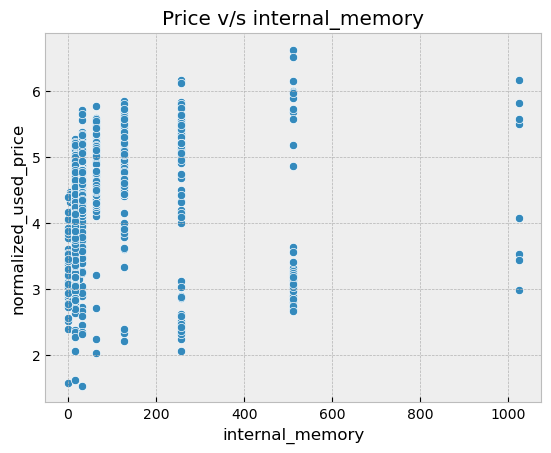

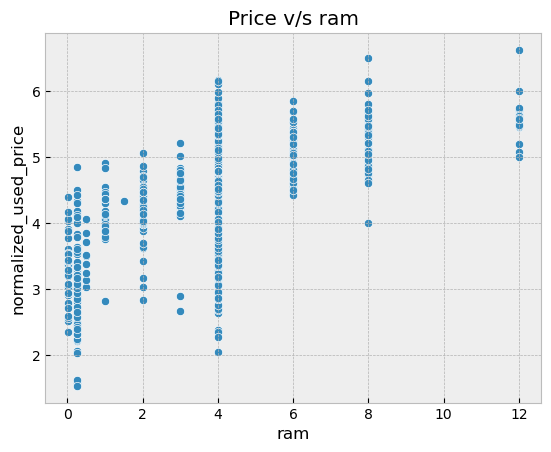

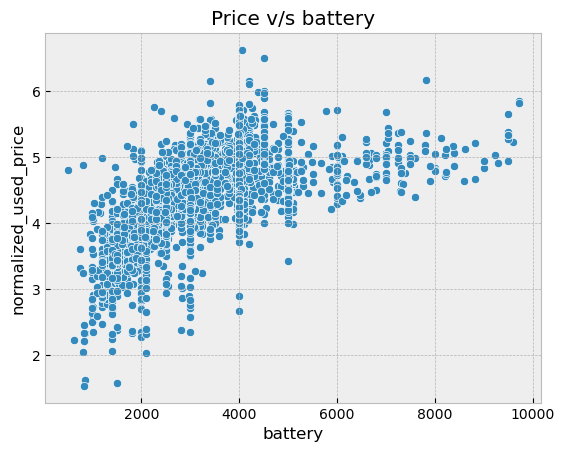

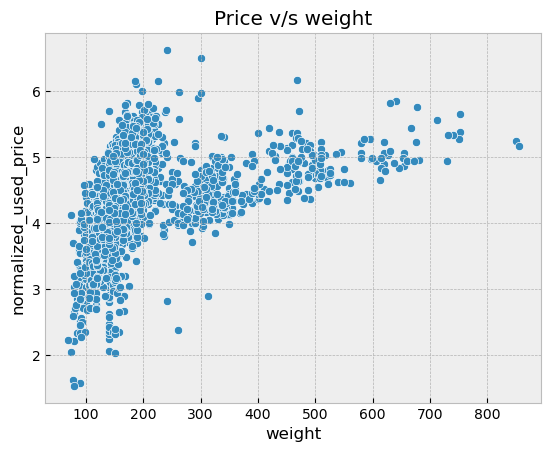

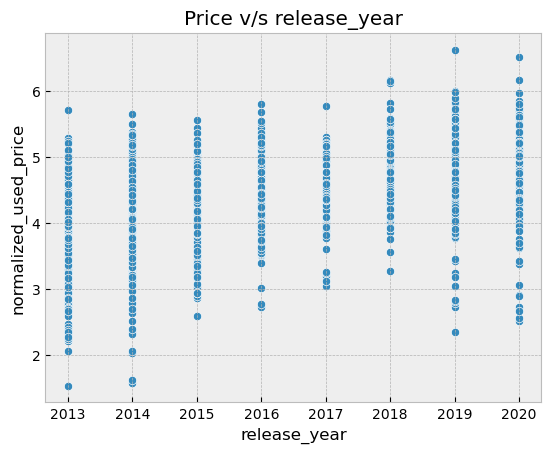

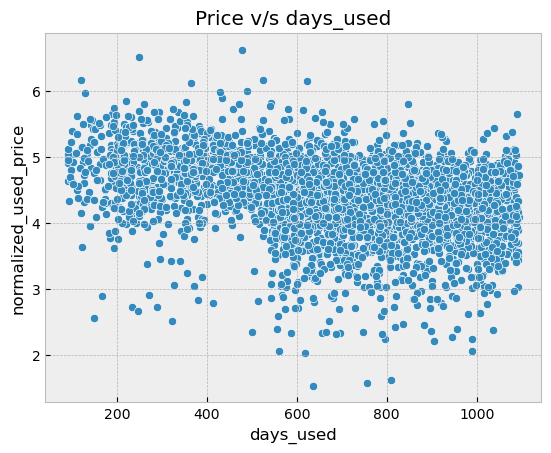

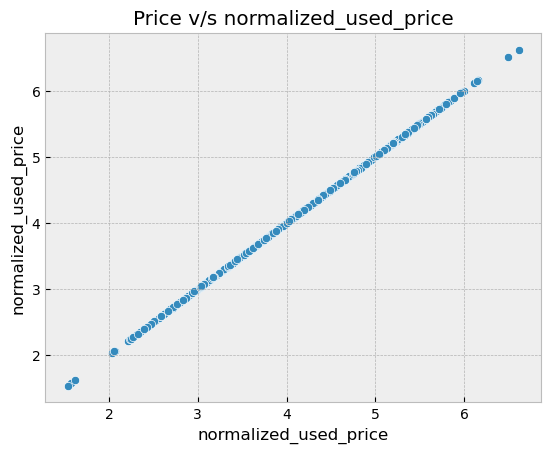

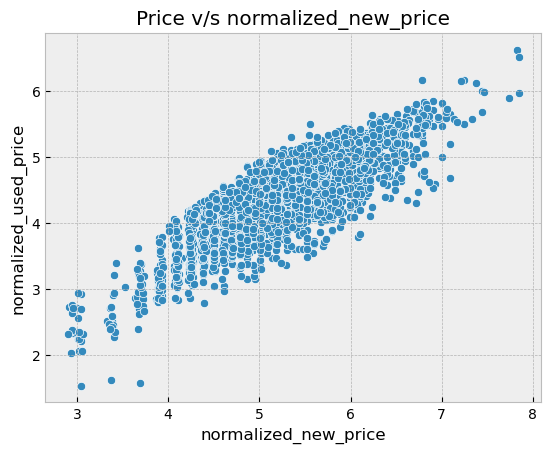

In [11]:
for column in df.columns:
    if col != 'normalized_used_price':
        sns.scatterplot(x=df[column],y=df['normalized_used_price'])
        plt.title(f"Price v/s {column}")
        plt.show()

#Which features correlate with price


In [12]:
#Clean currency columns
def clean_price(x):
    if isinstance(x, str):
        x = x.replace("₹","").replace(",","")
    try:
        return float(x)
    except:
        return np.nan

df['normalized_used_price'] = df['normalized_used_price'].apply(clean_price)
df.dropna(subset=['normalized_used_price'], inplace=True)


In [13]:
#Useful features selected
features=['screen_size','rear_camera_mp','front_camera_mp','internal_memory','ram','battery','weight','days_used']
X=df[features].copy()
y=df['normalized_used_price'].values



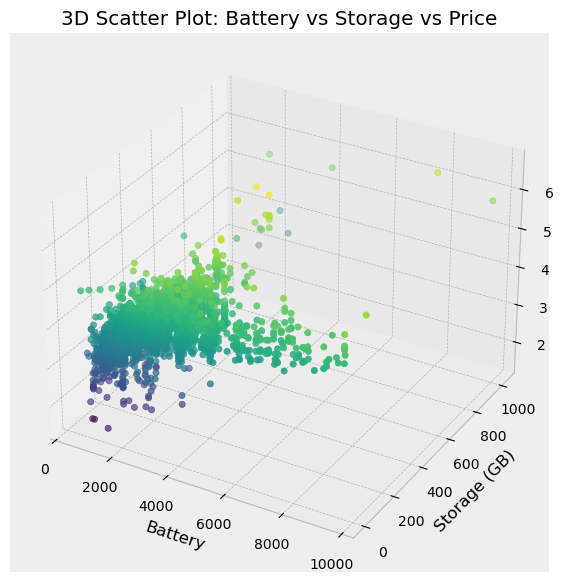

In [36]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df["battery"], df["internal_memory"], df["normalized_used_price"], c=df["normalized_used_price"], cmap="viridis")

ax.set_xlabel("Battery")
ax.set_ylabel("Storage (GB)")
ax.set_zlabel("Price")
ax.set_title("3D Scatter Plot: Battery vs Storage vs Price")

plt.show()


In [14]:
# Polynomial Generator
from itertools import combinations
def add_poly_features(X,degree=2):
    Xp=X.copy()
    cols=X.columns
    for c in cols:
        Xp[f"{c}^2"]=X[c]**2
    for a,b in combinations(cols,2):
        Xp[f"{a}*{b}"]=X[a]*X[b]
    return Xp

X_poly=add_poly_features(X)
X_poly.head()

,screen_size,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,days_used,screen_size^2,rear_camera_mp^2,...,internal_memory*ram,internal_memory*battery,internal_memory*weight,internal_memory*days_used,ram*battery,ram*weight,ram*days_used,battery*weight,battery*days_used,weight*days_used
0,14.50,13.0,5.0,64.0,3.0,3020.0,146.0,127,210.2500,169.0,...,192.0,193280.0,9344.0,8128.0,9060.0,438.0,381.0,440920.0,383540.0,18542.0
1,17.30,13.0,16.0,128.0,8.0,4300.0,213.0,325,299.2900,169.0,...,1024.0,550400.0,27264.0,41600.0,34400.0,1704.0,2600.0,915900.0,1397500.0,69225.0
2,16.69,13.0,8.0,128.0,8.0,4200.0,213.0,162,278.5561,169.0,...,1024.0,537600.0,27264.0,20736.0,33600.0,1704.0,1296.0,894600.0,680400.0,34506.0
3,25.50,13.0,8.0,64.0,6.0,7250.0,480.0,345,650.2500,169.0,...,384.0,464000.0,30720.0,22080.0,43500.0,2880.0,2070.0,3480000.0,2501250.0,165600.0
4,15.32,13.0,8.0,64.0,3.0,5000.0,185.0,293,234.7024,169.0,...,192.0,320000.0,11840.0,18752.0,15000.0,555.0,879.0,925000.0,1465000.0,54205.0


In [15]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X_poly,y,test_size=0.2,random_state=42)

# 20% of dataset becomes test data
# 80% is training data

In [16]:
#Scaling the train and test dataset
mu=X_train.mean(axis=0)
sigma=X_test.std(axis=0)
X_train_scaled=(X_train-mu)/sigma
X_test_scaled=(X_test-mu)/sigma

In [17]:
#Adding Bias Column(y-intercept)

def add_bias(X):
    return np.hstack([np.ones((X.shape[0],1)),X])

In [18]:
#Cost function
def compute_cost(X,y,theta):
    m=len(y)
    pred=X.dot(theta)
    return (1/(2*m))*np.sum((pred-y)**2)


In [30]:
#Gradient Descent
def gradient_descent(X,y,theta,alpha=0.01,n_iters=3000):
    m=len(y)
    cost_history=[]
    for i in range(n_iters):
        pred=X.dot(theta)
        gradient=(1/m)*(X.T.dot(pred-y))
        theta=theta-alpha*gradient
        cost_history.append(compute_cost(X,y,theta))
        if i%500==0:
            print(f"Iteration {i} | Cost: {cost_history[-1]:.4f}")
    return theta,cost_history


Iteration 0 | Cost: 8.6492
Iteration 500 | Cost: 0.0378
Iteration 1000 | Cost: 0.0370
Iteration 1500 | Cost: 0.0367
Iteration 2000 | Cost: 0.0364
Iteration 2500 | Cost: 0.0363
Iteration 3000 | Cost: 0.0362
Iteration 3500 | Cost: 0.0361
Iteration 4000 | Cost: 0.0361
Iteration 4500 | Cost: 0.0360
Iteration 5000 | Cost: 0.0360
Iteration 5500 | Cost: 0.0360


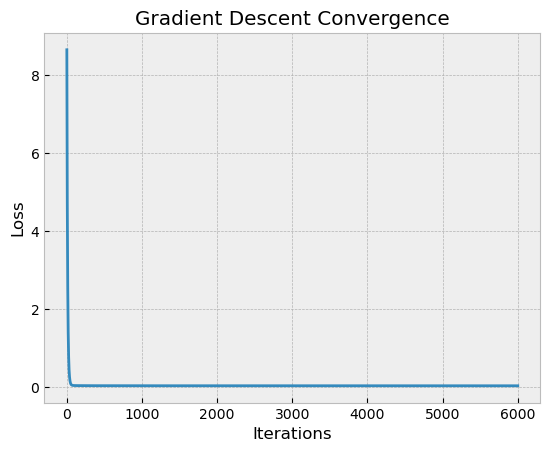

In [32]:
Xb_train=add_bias(X_train_scaled)
Xb_test=add_bias(X_test_scaled)
theta0=np.zeros((Xb_train.shape[1],1))
theta_manual,history=gradient_descent(Xb_train,y_train.reshape(-1,1),theta0,alpha=0.05,n_iters=6000)
import matplotlib.pyplot as plt

plt.plot(history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Gradient Descent Convergence")
plt.show()

In [21]:
y_pred_train=Xb_train.dot(theta_manual).flatten()
y_pred_test=Xb_test.dot(theta_manual).flatten()

In [22]:
def rmse(y,p):
    return np.sqrt(mean_squared_error(y,p))
print("Train RMSE: ",rmse(y_train,y_pred_train))
print("Test RMSE: ",rmse(y_test,y_pred_test))
print("Test R2: ",r2_score(y_test,y_pred_test))

Train RMSE:  0.26811662693028515
Test RMSE:  0.26938909878188066
Test R2:  0.7763748791214038


In [23]:
#Scikit-learn Polynomial Regression
poly=PolynomialFeatures(degree=2,include_bias=False)
X2=poly.fit_transform(X)
X_train2,X_test2,y_train2,y_test2=train_test_split(X2,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(X_train2,y_train2)
sk_pred=model.predict(X_test2)
print("Sklearn RMSE:",rmse(y_test2,sk_pred))
print("Sklearn R2:",r2_score(y_test2,sk_pred))

Sklearn RMSE: 0.26989151146948054
Sklearn R2: 0.775539976244812


In [24]:
# Business Insights
coef_df=pd.DataFrame({
    "feature":X_poly.columns,
    "coef":theta_manual.flatten()[1:]
})
coef_df["abs"]=coef_df["coef"].abs()
coef_df.sort_values("abs",ascending=False).head(10)

,feature,coef,abs
1,rear_camera_mp,0.480913,0.480913
2,front_camera_mp,0.381339,0.381339
16,screen_size*rear_camera_mp,-0.300431,0.300431
6,weight,0.222453,0.222453
4,ram,0.203631,0.203631
0,screen_size,0.193056,0.193056
40,ram*days_used,-0.157716,0.157716
23,rear_camera_mp*front_camera_mp,-0.139193,0.139193
24,rear_camera_mp*internal_memory,0.118982,0.118982
12,ram^2,-0.102268,0.102268


Higher the abs,higher its effect on the price

In [25]:
def predict_phone_price(specs):
    row = pd.DataFrame([specs])
    row_poly = add_poly_features(row)
    row_scaled = (row_poly - mu) / sigma
    row_b = add_bias(row_scaled.values)
    return float(row_b.dot(theta_manual))


In [29]:
phone = {
    "screen_size": 6.5,
    "rear_camera_mp": 64,
    "front_camera_mp": 32,
    "internal_memory": 128,
    "ram": 8,
    "battery": 5000,
    "weight": 180,
    "days_used": 300
}


predict_price = predict_phone_price(phone)
print("Predicted price = ₹", float(predict_price)*1000)


Predicted price = ₹ 5292.021167652121


C:\Users\rksan_amz5yv3\AppData\Local\Temp\ipykernel_19220\3290883321.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(row_b.dot(theta_manual))


In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

import pickle
pickle.dump(model, open("model.pkl", "wb"))

